<span style="font-size:12px">

### 다양한 모델을 결합한 앙상블
- 앙상블
- 다수결 투표 앙상블 (voting)
- 배깅(Bagging)
- 에이다부스트(AdaBoost)
- 그레이던트 부스팅 & XGBoost
- 모델성능 평가 및 비교

<span style="font-size:12px">

- 단일 모델의 한계
    - 과대 적합(Overfitting) : 학습 데이터에 너무 맞춰져있어서 새로운 데이터에 대한 성능저하
    - 과소 적합(underfitting) : 모델이 너무 단순해서 제대로 학습이 안됨(성능저하)
    - 높은 분산(Hight Variance) : 학습데이터가 조금만 바뀌어도 모델이 크게 달라지는 현상
    - 높은 편향(High Bias) : 모델이 진짜 패턴을 포착하지 못함

- 앙상블 (집단지성)
    - voting : 여러 모델이 같은 문제를 보고 '이게답이야'하고 투표하는 방법
    - 배깅 : 같은 모델 여러개를, 서로 다른 데이터셋(부트스트랩)을 사용  : 분산을 감소시킴
<br>    ex.Randomforest
    - 부스팅 : 모델이 순서대로 학습하면서, 앞의 실수를 뒤가 보완 (약한 학습기를 강화)  : 편향을 감소시킴 --> 더 정확해짐
<br>     ex. AdaBoost, XGBoost,Gradient Boosting
    - 스태킹 : 다른 모델을 층층이 쌓아서 결합
<br>     ex. 1단계(Base model) : 여러모델 예측(ex.로지스틱, 랜덤포레스트, SVM 등)
<br>     ex. 2단계(Meta model) : 위 모델 결과를 받아, "최종 정답" 예측 (보통 로지스틱회귀 사용)

<span style="font-size:12px">


- Voting : 여러 모델을 학습시켜서 투표
    - Hard Voting : 다수결 투표
<br>       A: 고양이, B : 강아지, C : 고양이 ==> 고양이로 투표
    - Soft Voting : 가중치 투표 - 확룔을 보고 결정, 보통 Hard Voting 보다 성능이 좋음
<br>        고양이, 강아지 각각의 확률
<br>        A: (0.9, 0.1)
<br>        B: (0.4, 0.6)
<br>        C: (0.6, 0.2)
<br>        ==> 평균 확률로 판단
<br>
<br>
- Bagging (Bootstrap Aggregation) 같은 모델 여러개를 다른 데이터셋(부트스트랩 샘플)으로 여러번 학습시켜 결합
    - Bootstrap : 원본 데이터 1000개면 중복을 허용해서 1000번 뽑아 훈련세트1, 훈련세트2, 훈련세트3, ... 을 만듬
    - Aggregation : 순차적으로 학습을 하고난 후 같은 모델 여러개를 투표(voting)해서 최종 결론
    - 효과 : 과적합을 방지/ 즉, 모델의 분산을 줄여줌 
    - 대표모델
         - 가장 유명한 건 RandomForest
<br>           이유: 랜덤포레스트는 여러 결정나무를 만들고, 각 나무가 Bagging 방식으로 학습됨
         - 다른 모델 가능 : BaggingClassifier (sklearn) → 기본 모델로 Decision Tree 외에 SVM, KNN 등 가능
<br>단, 같은 모델을 여러 개 쓰는 게 원칙이에요.
<br>
<br>
- Boosting
    - 모델들이 순서대로 학습, 앞 모델의 실수를 뒷 모델이 보완
        - 모델1이 전체 데이터로 학습하고 예측
        - 모델1이 틀린 문제를 찾는다
        - 틀린문제를 더 높은 가중치(중요도)를 부여
        - 모델2가 틀리기 쉬운문제들을 좀더 학습
        - 모델2가 틀린 문제를 찾는다
        - 모델3은 모델1,2가 틀린문제에 집중 -- 가중치 부여
        - 반복
    - 결론 
        - 예측을 합친다. 성적이 더 좋은 모델의 가중치를 부여해서 최종 결론
        - 편향(Bias)을 줄여준다
    - 모델 종류 : daBoost, XGBoost,Gradient Boosting

- 스태킹
    - 1 base model : 여러개의 모델을 훈련 (예: 로지스틱, 랜덤포레스트, SVM 등)
    - 2 meta model 
        - 1단계 모델들이 예측한 값들을 모음
        - 예측한 값을 훈련데이터(특성)로 사용 (보통 Losistic Regression 사용)
    - 결론
        - 새로운 데이터를 최종모델을 이용해서 결론을 도출



<span style="font-size:12px">

🧠 정리

| 방법       | 주요 아이디어        | 대표 모델             | 줄이는 것        |
| -------- | -------------- | ----------------- | ------------ |
| Voting   | 여러 모델이 투표      | Logistic + SVM 등  | -            |
| Bagging  | 같은 모델 + 다른 데이터 | RandomForest      | 분산(Variance) |
| Boosting | 순차 학습, 틀린 것 보완 | AdaBoost, XGBoost | 편향(Bias)     |
| Stacking | 서로 다른 모델 조합    | base-Model --> Meta-Model        | 일반화 성능       |


voting_hard :               precision    recall  f1-score   support

           0       1.00      0.88      0.94        51
           1       0.89      1.00      0.94        49

    accuracy                           0.94       100
   macro avg       0.95      0.94      0.94       100
weighted avg       0.95      0.94      0.94       100

voting_soft :               precision    recall  f1-score   support

           0       1.00      0.92      0.96        51
           1       0.92      1.00      0.96        49

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

lr : 0.88
svm : 0.93
knn : 0.97
voting_hard : 0.94
voting_soft : 0.96


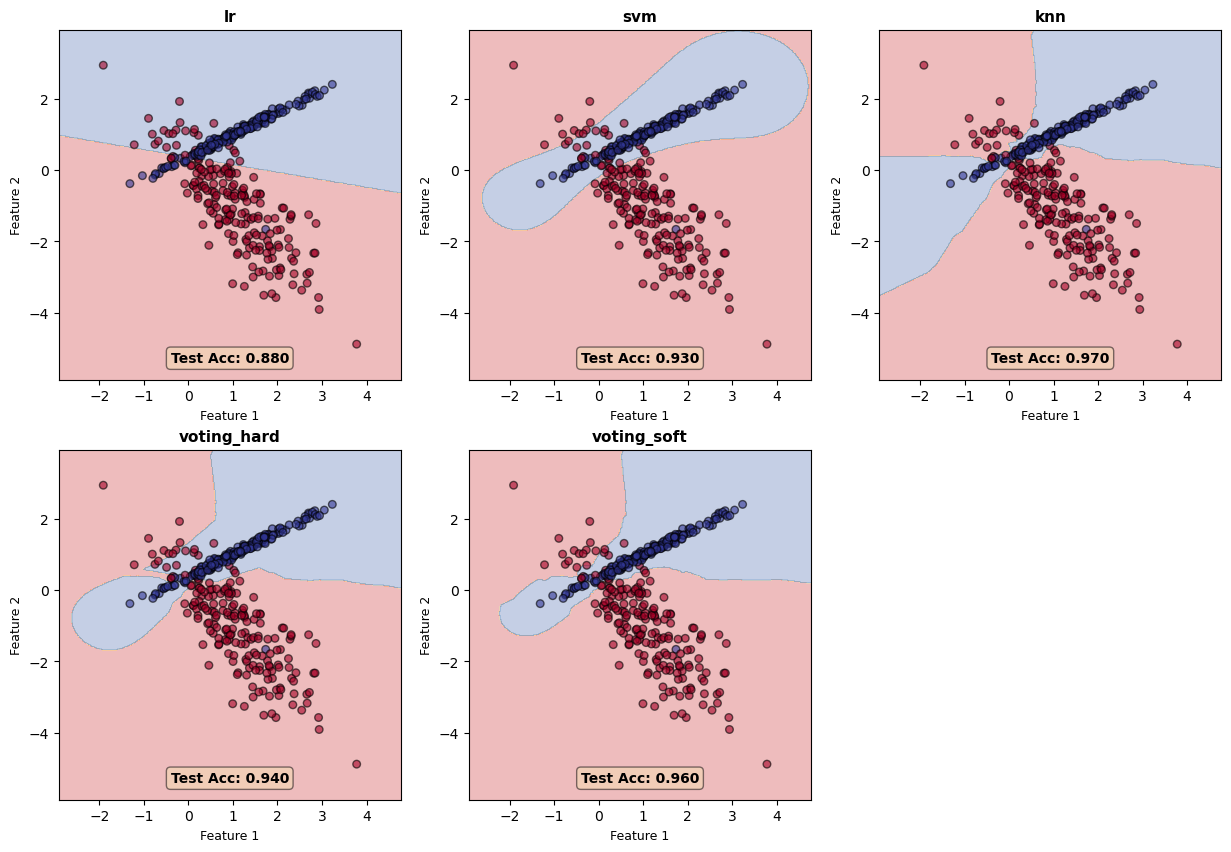

In [84]:
# 데이터 생성
from sklearn.datasets import make_classification
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

X,y = make_classification(n_samples=500, n_features=2, random_state=42, n_redundant=0, n_clusters_per_class=1)
#
np.unique(y,return_counts=True)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# 개별모델 생성 / 학습
lr = LogisticRegression(random_state=42)
svm = SVC(random_state=42, probability=True)
knn = KNeighborsClassifier()
lr.fit(X_train, y_train) ; svm.fit(X_train, y_train) ; knn.fit(X_train, y_train)

# 보팅 앙상블
voting_hard = VotingClassifier(estimators=[('lr',lr), ('svm', svm), ('knn', knn)], voting='hard')
voting_soft = VotingClassifier(estimators=[('lr',lr), ('svm', svm), ('knn', knn)], voting='soft')

voting_hard.fit(X_train, y_train)
voting_soft.fit(X_train, y_train)
print (f'voting_hard : {classification_report (y_test, voting_hard.predict(X_test))}')
print (f'voting_soft : {classification_report (y_test, voting_soft.predict(X_test))}')


# 출력
models = [
    ('lr', lr),
    ('svm', svm),
    ('knn', knn),
    ('voting_hard', voting_hard),
    ('voting_soft', voting_soft)
]

for label, model in models:
    print(f'{label} : {model.score(X_test, y_test)}')


#################################################################
# 결정 경계 시각화
def plot_decision_boundary(model, X, y, title, ax):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu,
              edgecolor='black', s=30, alpha=0.6)
    ax.set_title(title, fontsize=11, weight='bold')
    ax.set_xlabel('Feature 1', fontsize=9)
    ax.set_ylabel('Feature 2', fontsize=9)

# 5개 서브플롯 생성
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (title ,model) in enumerate(models):
  row = idx // 3
  col = idx % 3
  plot_decision_boundary(model, X_train, y_train, title, axes[row, col])

  # 정확도 표시
  score = model.score(X_test, y_test)
  axes[row, col].text(0.5, 0.05, f'Test Acc: {score:.3f}',
                      transform=axes[row, col].transAxes,
                      ha='center', fontsize=10, weight='bold',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 마지막 서브플롯 제거
axes[1, 2].remove()


<span style="font-size:12px">

1. 그래프 구성
- 각 서브플롯은 서로 다른 모델을 나타냅니다. (lr, svm, knn, voting_hard, voting_soft)
- 배경 색: 모델이 예측한 클래스 영역
  - 빨간색: 모델이 1로 예측한 영역
  - 파란색: 모델이 0으로 예측한 영역
- 점 (scatter plot): 실제 데이터 포인트
  - 빨간 점: 클래스 1
  - 파란 점: 클래스 0
- Test Acc: 테스트 데이터에서 모델 정확도

2. 각 모델 특징과 결정 경계
- **lr (Logistic Regression)**
  - 결정 경계: 직선 (선형 모델)
  - Test Acc: 0.88
  - 장점: 단순하고 빠름
  - 단점: 데이터가 선형으로 구분되지 않으면 성능 한계

- **svm (Support Vector Machine)**
  - 결정 경계: 약간 곡선 (커널 사용 시 비선형 가능)
  - Test Acc: 0.93
  - 장점: 마진 최대화, 비선형 경계 가능
  - 단점: 계산량이 많을 수 있음

- **knn (k-Nearest Neighbors)**
  - 결정 경계: 불규칙한 곡선 (데이터 포인트 주변 형태 반영)
  - Test Acc: 0.97
  - 장점: 유연함, 데이터 패턴 잘 반영
  - 단점: 데이터 많으면 느림, 과적합 가능

- **앙상블 (Voting Classifier)**
  - hard voting: 다수결
  - soft voting: 확률 평균
  - Test Acc: hard 0.94, soft 0.96
  - 장점: 단일 모델보다 일반화 성능이 좋음

3. 해석
- 결정 경계 모양 → 모델이 데이터를 어떻게 구분하는지 보여줌
- 선형 경계 → 단순 모델 (lr)
- 비선형/복잡한 경계 → flexible 모델 (knn)
- Test Accuracy → 경계가 데이터에 잘 맞으면 정확도 높음
- knn이 가장 높음 (0.97) → 데이터에 매우 잘 맞춤
- 앙상블도 단일 모델보다 성능 향상


<span style="font-size:11px">

#### 🎯 make_classification

from sklearn.datasets import make_classification


| 파라미터                        | 의미                             | 쉽게 말하면                        |
| --------------------------- | ------------------------------ | ----------------------------- |
| **n_samples=500**           | 생성할 샘플(데이터) 개수                 | 데이터 500개 만들기                  |
| **n_features=2**            | 각 데이터의 **특징(열)** 개수            | X의 열이 2개 (예: 키, 몸무게처럼 2가지 특징) |
| **n_informative=2 (기본값=2)** | 실제로 **정답(y)에 영향을 주는 특징 수**     | 진짜 중요한 특징 몇 개냐                |
| **n_redundant=0**           | **다른 특징과 선형조합으로 만들어진 중복 특징 수** | 의미는 없지만 다른 특징에서 계산된 열 개수      |
| **n_repeated=0**            | 단순히 **복사된 특징 수**               | 중복 복사된 열 (보통 0으로 둬요)          |
| **n_clusters_per_class=1**  | 각 클래스가 가질 **클러스터(덩어리)** 수      | 클래스별로 점이 몇 군데로 퍼져 있을지         |
| **n_classes=2 (기본값=2)**     | 분류할 클래스(정답) 개수                 | 2면 이진분류 (예: 스팸/햄)             |
| **flip_y=0.01 (기본값)**       | **레이블을 랜덤하게 뒤집는 비율**           | 일부러 1% 정도 오류 넣기               |
| **class_sep=1.0 (기본값)**     | 클래스 간의 **거리(분리 정도)**           | 값이 크면 두 클래스가 더 멀리 떨어짐         |
| **random_state=42**         | 랜덤 시드 (재현용)                    | 항상 같은 데이터가 나오게 고정             |
| **weights=None**            | 각 클래스의 비율                      | 예: `[0.7, 0.3]`이면 불균형 데이터     |


In [ ]:
# 질문 : 어떤 종류의 모델들을 조합하면 good?
# 다양성이 중요 : 서로다른 가정을 가진 모델을 조합
# 선형모델 + 비선형 모델 + 인스턴스기반(KNN)

(178, 13) (178,)
Single Tree accuracy: 0.6666666666666666
Bagging accuracy: 0.7222222222222222


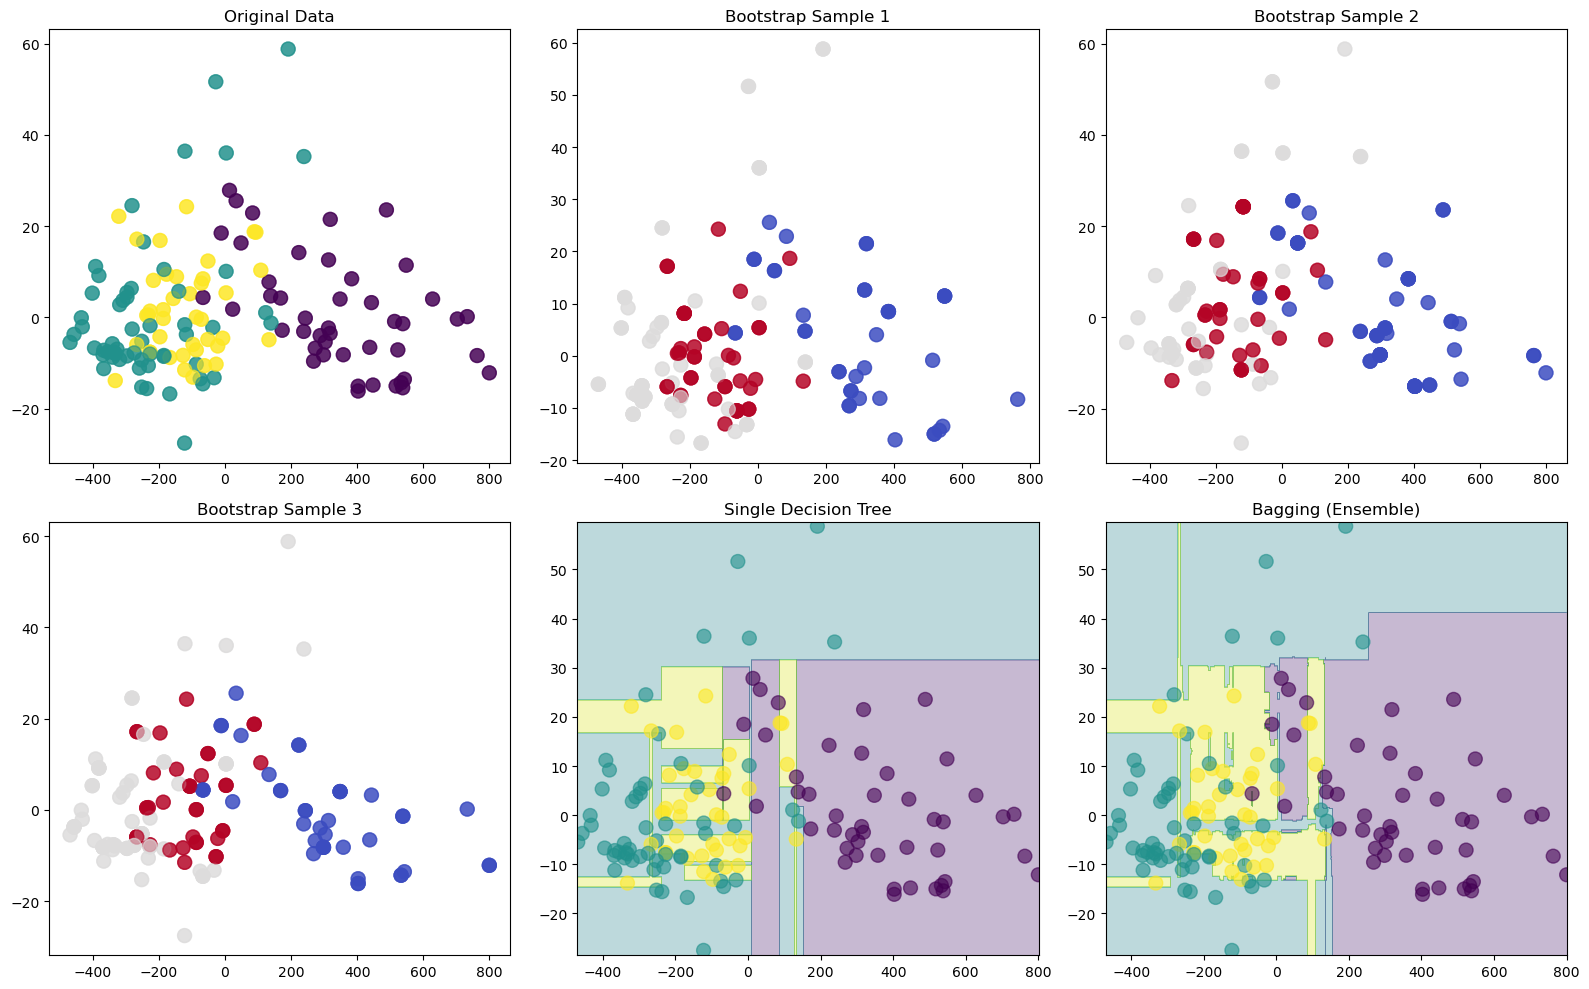

In [ ]:
# 배깅 (bagging)
    # Bootstrap Aggregating
    # 같은 알고리즘을 다른 데이터셋(부트스트랩 샘플)로 여러번 학습시켜 결합
    # 대표적인 모델 : RandomForest

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

X,y = load_wine(return_X_y=True)
print(X.shape, y.shape)

# 시각화를 위해서
X_pca = PCA(n_components=2, random_state=42).fit_transform(X)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 모델 정의

tree = DecisionTreeClassifier(random_state=42)
bagging = BaggingClassifier(   
estimator=DecisionTreeClassifier(),
n_estimators=100, random_state=42)

# 학습 ... 지금 하기 시각화에는 필요없는 코딩
# tree.fit(X_train, y_train)
# bagging.fit(X_train, y_train)

# 시각화
fig = plt.figure(figsize=(16,10))
# 1.원본데이터
ax1 = plt.subplot(2,3,1)
ax1.scatter(X_train[:,0], X_train[:,1], c=y_train, s=100, alpha=0.6, cmap='viridis')
ax1.set_title(f'original data')

# 2.부트스트랩 
np.random.seed(42)
for i in range(3):
    ax = plt.subplot(2,3,i+2)
    # 부트스트랩 샘플링
    n_samples = len(X_train)
    bootstrap_index = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot = X_train[bootstrap_index]
    y_boot = y_train[bootstrap_index]
    ax.scatter(X_boot[:,0], X_boot[:,1], c=y_boot, s=100, alpha=0.6, cmap='coolwarm')
    ax.set_title(f'Bootstrap Sample {i+1}')

print('====================================')

########## [GPT] 배깅 최종 결정 경계 시각화 : 여러개 decision tree 학습 후 투표통해 예측한 결과 2D 평면에 
# 1. 결정경계 함수 정의
def plot_decision_boundary(model, X, y, title, ax):
    # 격자 생성
    h = 0.2
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    # 예측
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # 경계 시각화
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X[:,0], X[:,1], c=y, s=100, alpha=0.6, cmap='viridis')
    ax.set_title(title)


# 2. Bagging 학습 후 결정 경계 그리기
# 모델 학습
tree.fit(X_train, y_train)
bagging.fit(X_train, y_train)


# 원본 데이터
ax1 = plt.subplot(2,3,1)
ax1.scatter(X_train[:,0], X_train[:,1], c=y_train, s=100, alpha=0.6, cmap='viridis')
ax1.set_title('Original Data')

# 부트스트랩 샘플
np.random.seed(42)
for i in range(3):
    ax = plt.subplot(2,3,i+2)
    n_samples = len(X_train)
    bootstrap_index = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot = X_train[bootstrap_index]
    y_boot = y_train[bootstrap_index]
    ax.scatter(X_boot[:,0], X_boot[:,1], c=y_boot, s=100, alpha=0.6, cmap='coolwarm')
    ax.set_title(f'Bootstrap Sample {i+1}')



print("Single Tree accuracy:", tree.score(X_test, y_test))
print("Bagging accuracy:", bagging.score(X_test, y_test))

# 단일 트리 결정 경계
ax5 = plt.subplot(2,3,5)
plot_decision_boundary(tree, X_train, y_train, 'Single Decision Tree', ax5)

# Bagging 결정 경계
ax6 = plt.subplot(2,3,6)
plot_decision_boundary(bagging, X_train, y_train, 'Bagging (Ensemble)', ax6)

plt.tight_layout()
plt.show()



<span style="font-size:12px">

1. 의미
- 이 시각화는 Bagging(Bootstrap Aggregating)의 핵심 아이디어를 보여줍니다.
  - 같은 모델(Decision Tree)을 서로 다른 부트스트랩 샘플로 학습시킴
  - 결과를 평균 또는 투표로 결합하면 성능이 안정적이고 과적합을 줄일 수 있음
- 각 부트스트랩 샘플에서 학습한 모델은 약간씩 다른 데이터 분포를 가지고 있기 때문에 서로 다르게 학습됨
- 여러 모델의 투표(Aggregation)를 통해, 단일 모델보다 예측이 더 안정적임

<br>

2. 시각적 특징
- 원본 데이터: 모든 클래스 포인트가 잘 분포
- 부트스트랩 샘플:
  - 일부 포인트는 중복되어 나타남
  - 일부 포인트는 사라짐
  - 클래스 비율도 약간 달라짐

<br>
💡 핵심 포인트
- Bagging은 데이터 일부를 랜덤하게 뽑아 학습하기 때문에 각 모델이 조금씩 다른 학습을 하게 되고, 이 차이가 최종 앙상블 성능 향상으로 이어짐


In [ ]:
# 에이다 부스트(AdaBoost)
    # 약한 학습기들을 순차적으로 결합해서 강한 학습기를 만듦
        # 이전 모델이 틀린 샘플에 더 집중
        # 각 모델은 이전 모델의 실수를 보완
        # 편향감소가 주요 목표

# 배깅 vs 부스팅
    # 학습방식 : 병렬(독립적) | 순차적(의존성)
    # 샘플 : 부트스트랩 | 가중치 조절
    # 대표 모델 : RandomForest | AdaBoost, GradientBoosting, XGBoost

# 작동원리 AdaBoost
    # 모든 샘플에 동일한 가중치 부여
    # 약한 학습기를 학습 
    # 잘못 분류된 샘플의 가중치 증가
    # 반복
    # 최종적으로 모든 학습기를 가중 투표로 결합

AdaBoost :               precision    recall  f1-score   support

           0       0.97      0.90      0.94        41
           1       0.92      0.98      0.95        49

    accuracy                           0.94        90
   macro avg       0.95      0.94      0.94        90
weighted avg       0.95      0.94      0.94        90

tree 일반 :               precision    recall  f1-score   support

           0       0.95      0.90      0.93        41
           1       0.92      0.96      0.94        49

    accuracy                           0.93        90
   macro avg       0.94      0.93      0.93        90
weighted avg       0.93      0.93      0.93        90

train : 0.8762 / test : 0.9444


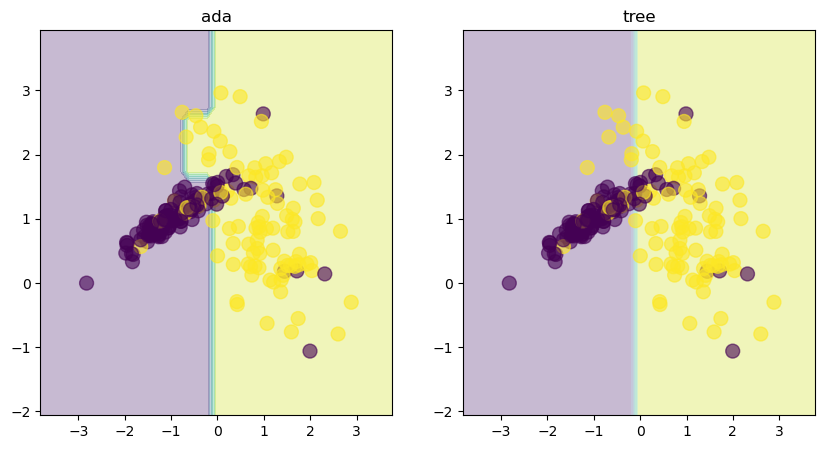

In [ ]:
##### AdaBoost  : 틀린 문제에 대해서 (오차가 큰) 가중치를 높임.
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report

np.random.seed(42)

X,y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2, 
                    n_clusters_per_class=1, flip_y=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

tree=DecisionTreeClassifier(max_depth=1, random_state=42)
ada=AdaBoostClassifier(
    estimator= DecisionTreeClassifier(max_depth=1),
    n_estimators=50, learning_rate=1.0, random_state=42
)   #n_estimators=50 일때와, n_estimators=500 일때 결과값 차이가 많이 다름.
ada.fit(X_train, y_train)
tree.fit(X_train, y_train)
print(f'AdaBoost : {classification_report(y_test, ada.predict(X_test))}')
print(f'tree 일반 : {classification_report(y_test, tree.predict(X_test))}')
print(f'train : {ada.score(X_train, y_train):.4f} / test : {ada.score(X_test, y_test) :.4f}')
# 출력: train : 0.8762 / test : 0.9444
# train score = 0.8762 → 학습 데이터에서의 정확도 (모델이 학습 데이터에 얼마나 잘 맞췄는지)
# test score = 0.9444 → 테스트 데이터(모델이 처음 보는 데이터)에서의 정확도 (일반화 성능)
# 일반적으로는 train 점수 ≥ test 점수
# 왜냐면 모델이 학습 데이터에 더 익숙하기 때문이에요.
# 그런데 지금은 반대로 train(0.8762) < test(0.9444)
# 이유1.데이터 분할(random_state=42)에 따른 우연
# → 테스트 데이터가 학습에 비해 구분이 쉬운 샘플로 구성됐을 수 있음.
# 이유2. AdaBoost의 일반화 효과
# → 여러 약한 분류기(깊이 1짜리 의사결정트리)를 조합해서 “잡음에 둔감한” 모델을 만들기 때문에 오히려 테스트 데이터에서 더 잘 맞출 때도 있음.
# 이유3. flip_y=0.1 (10% 레이블 노이즈)
# → 학습 데이터 안에 일부 잘못된 라벨이 있어서 train 성능이 조금 떨어졌을 가능성 



# 결정경계
fig, axes=plt.subplots(1,2, figsize=(10,5))
plot_decision_boundary(ada, X_train, y_train, title='ada', ax=axes[0])
plot_decision_boundary(tree, X_train, y_train, title='tree', ax=axes[1])



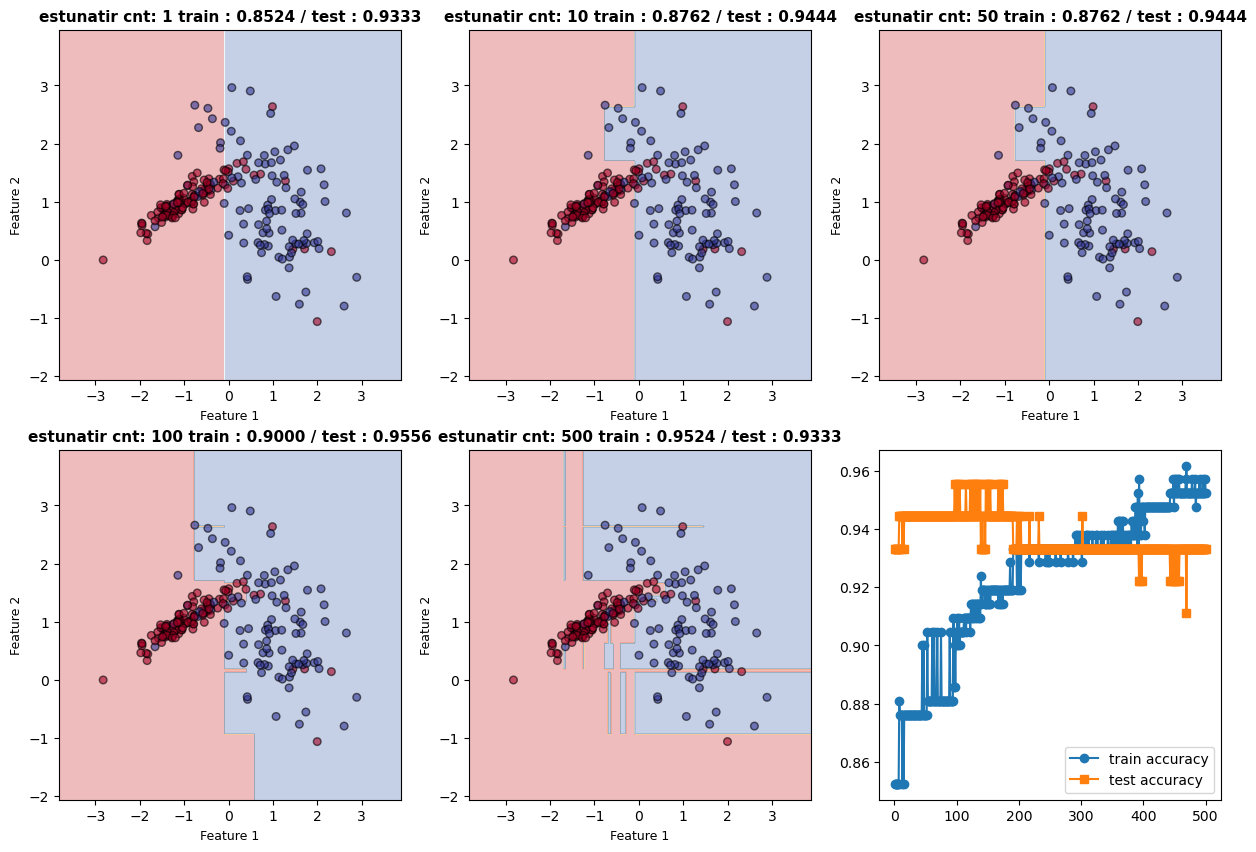

In [83]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report

np.random.seed(42)

X,y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2, 
                    n_clusters_per_class=1, flip_y=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

#변화추이
fig, axes = plt.subplots(2,3, figsize=(15,10))
n_estimators_lists = [1,10,50,100,500]

for idx, n_est in enumerate(n_estimators_lists):
    ada=AdaBoostClassifier(
        estimator= DecisionTreeClassifier(max_depth=1),
        n_estimators=n_est, 
        learning_rate=1.0, 
        random_state=42
    )   
    ada.fit(X_train, y_train)
    # print(classification_report(y_test, ada.predict(X_test)))
    title = f'estunatir cnt: {n_est} train : {ada.score(X_train, y_train):.4f} / test : {ada.score(X_test, y_test) :.4f}'
    # print(title)


    # AdaBoost : 틀린 문제에 대해서 (오차가 큰) 가중치를 높임.


    # 결정경계
    plot_decision_boundary(ada, X_train, y_train, title, axes[idx//3, idx%3])

# 학습곡선
train_score, test_score = [], []
for n in range(1,501):
    temp=AdaBoostClassifier(
    estimator= DecisionTreeClassifier(max_depth=1),
    n_estimators=n, 
    learning_rate=1.0, 
    random_state=42
    )   
    temp.fit(X_train, y_train)
    train_score.append(temp.score(X_train, y_train))
    test_score.append(temp.score(X_test, y_test))
axes[1,2].plot(range(1,501), train_score, label='train accuracy', marker='o')
axes[1,2].plot(range(1,501), test_score, label='test accuracy', marker='s')
axes[1,2].legend()

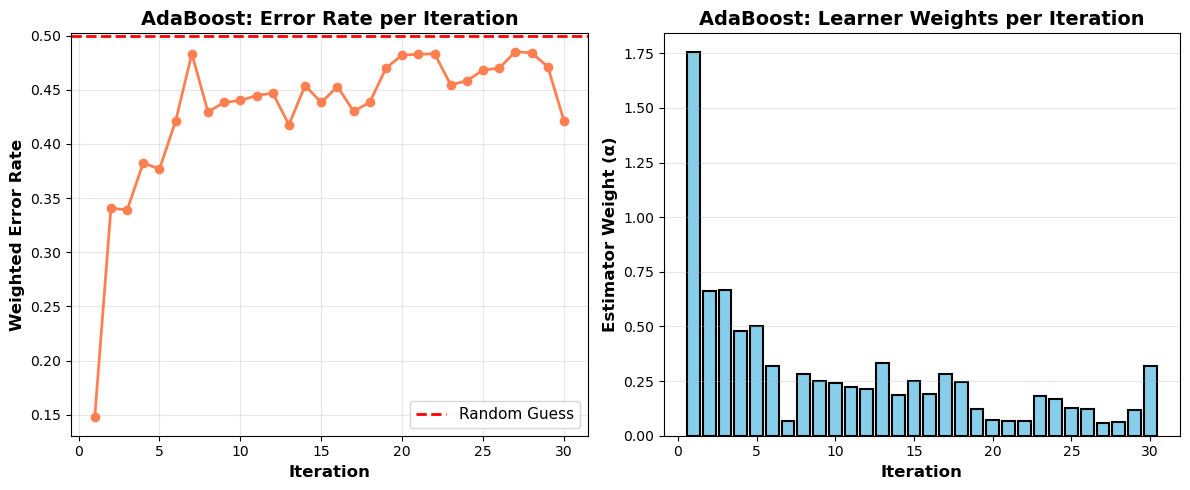

ADABOOST ANALYSIS
Number of Estimators: 50
Training Accuracy: 0.8762
Test Accuracy: 0.9444

First 10 Estimator Errors:
  Round  1: 0.1476
  Round  2: 0.3407
  Round  3: 0.3391
  Round  4: 0.3825
  Round  5: 0.3768
  Round  6: 0.4213
  Round  7: 0.4831
  Round  8: 0.4296
  Round  9: 0.4383
  Round 10: 0.4401

Last 10 Estimator Errors:
  Round  1: 0.4553
  Round  2: 0.4589
  Round  3: 0.4402
  Round  4: 0.4232
  Round  5: 0.4492
  Round  6: 0.4416
  Round  7: 0.4628
  Round  8: 0.4686
  Round  9: 0.4844
  Round 10: 0.4830

Last 10 Estimator Weights:
  Round  1: 0.1794
  Round  2: 0.1646
  Round  3: 0.2404
  Round  4: 0.3098
  Round  5: 0.2038
  Round  6: 0.2345
  Round  7: 0.1492
  Round  8: 0.1258
  Round  9: 0.0625
  Round 10: 0.0681


In [99]:
# 오차 감소 시각화
plt.figure(figsize=(12, 5))

# 왼쪽: 단계별 오차율
plt.subplot(1, 2, 1)
estimator_errors = ada.estimator_errors_[:30]  # 처음 30개만
plt.plot(range(1, len(estimator_errors) + 1), estimator_errors, 
         marker='o', linewidth=2, markersize=6, color='coral')
plt.axhline(y=0.5, color='r', linestyle='--', label='Random Guess', linewidth=2)
plt.xlabel('Iteration', fontsize=12, weight='bold')
plt.ylabel('Weighted Error Rate', fontsize=12, weight='bold')
plt.title('AdaBoost: Error Rate per Iteration', fontsize=14, weight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# 오른쪽: 학습기 가중치
plt.subplot(1, 2, 2)
estimator_weights = ada.estimator_weights_[:30]
plt.bar(range(1, len(estimator_weights) + 1), estimator_weights, 
        color='skyblue', edgecolor='black', linewidth=1.5)
plt.xlabel('Iteration', fontsize=12, weight='bold')
plt.ylabel('Estimator Weight (α)', fontsize=12, weight='bold')
plt.title('AdaBoost: Learner Weights per Iteration', fontsize=14, weight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('adaboost_errors_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 70)
print("ADABOOST ANALYSIS")
print("=" * 70)
print(f"Number of Estimators: {ada.n_estimators}")
print(f"Training Accuracy: {ada.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {ada.score(X_test, y_test):.4f}")
print(f"\nFirst 10 Estimator Errors:")
for i, error in enumerate(ada.estimator_errors_[:10], 1):
    print(f"  Round {i:2d}: {error:.4f}")

print(f"\nLast 10 Estimator Errors:")
for i, error in enumerate(ada.estimator_errors_[-10:], 1):
    print(f"  Round {i:2d}: {error:.4f}")


print(f"\nLast 10 Estimator Weights:")
for i, weight in enumerate(ada.estimator_weights_[-10:], 1):
    print(f"  Round {i:2d}: {weight:.4f}")
print("=" * 70)
